### Model Training

Import libraries.

In [76]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


Import data.

In [77]:
df = pd.read_csv('data/train.csv')

In [78]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Extract the selected attributes.


In [79]:
selected_cols = ['SalePrice','OverallQual','GrLivArea','GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF','OpenPorchSF','Neighborhood', 'MSZoning', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish','CentralAir']
df = df[selected_cols]
df.head()

,SalePrice,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,TotRmsAbvGrd,Fireplaces,WoodDeckSF,OpenPorchSF,Neighborhood,MSZoning,ExterQual,KitchenQual,BsmtQual,GarageFinish,CentralAir
0,208500,7,1710,2,856,2,2003,8,0,0,61,CollgCr,RL,Gd,Gd,Gd,RFn,Y
1,181500,6,1262,2,1262,2,1976,6,1,298,0,Veenker,RL,TA,TA,Gd,RFn,Y
2,223500,7,1786,2,920,2,2001,6,1,0,42,CollgCr,RL,Gd,Gd,Gd,RFn,Y
3,140000,7,1717,3,756,1,1915,7,1,0,35,Crawfor,RL,TA,Gd,TA,Unf,Y
4,250000,8,2198,3,1145,2,2000,9,1,192,84,NoRidge,RL,Gd,Gd,Gd,RFn,Y


Use log transformation for SalePrice and GrLivArea

In [80]:
df["SalePrice"] = np.log1p(df["SalePrice"])
df.head()

,SalePrice,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,TotRmsAbvGrd,Fireplaces,WoodDeckSF,OpenPorchSF,Neighborhood,MSZoning,ExterQual,KitchenQual,BsmtQual,GarageFinish,CentralAir
0,12.247699,7,1710,2,856,2,2003,8,0,0,61,CollgCr,RL,Gd,Gd,Gd,RFn,Y
1,12.109016,6,1262,2,1262,2,1976,6,1,298,0,Veenker,RL,TA,TA,Gd,RFn,Y
2,12.317171,7,1786,2,920,2,2001,6,1,0,42,CollgCr,RL,Gd,Gd,Gd,RFn,Y
3,11.849405,7,1717,3,756,1,1915,7,1,0,35,Crawfor,RL,TA,Gd,TA,Unf,Y
4,12.429220,8,2198,3,1145,2,2000,9,1,192,84,NoRidge,RL,Gd,Gd,Gd,RFn,Y


I generated the variable `Quality_Weighted_Area` using the formula `Quality_Weighted_Area` = `GrLivArea` x `OverallQual`.

In [81]:
df['Quality_Weighted_Area'] = df['GrLivArea'] * df['OverallQual']
remove_cols = ['GrLivArea', 'OverallQual']
df = df.drop(columns=remove_cols)
df.head()

,SalePrice,GarageCars,TotalBsmtSF,FullBath,YearBuilt,TotRmsAbvGrd,Fireplaces,WoodDeckSF,OpenPorchSF,Neighborhood,MSZoning,ExterQual,KitchenQual,BsmtQual,GarageFinish,CentralAir,Quality_Weighted_Area
0,12.247699,2,856,2,2003,8,0,0,61,CollgCr,RL,Gd,Gd,Gd,RFn,Y,11970
1,12.109016,2,1262,2,1976,6,1,298,0,Veenker,RL,TA,TA,Gd,RFn,Y,7572
2,12.317171,2,920,2,2001,6,1,0,42,CollgCr,RL,Gd,Gd,Gd,RFn,Y,12502
3,11.849405,3,756,1,1915,7,1,0,35,Crawfor,RL,TA,Gd,TA,Unf,Y,12019
4,12.429220,3,1145,2,2000,9,1,192,84,NoRidge,RL,Gd,Gd,Gd,RFn,Y,17584


Split X and y

In [82]:
X = df.drop(columns=['SalePrice'],axis=1)
X.head()

,GarageCars,TotalBsmtSF,FullBath,YearBuilt,TotRmsAbvGrd,Fireplaces,WoodDeckSF,OpenPorchSF,Neighborhood,MSZoning,ExterQual,KitchenQual,BsmtQual,GarageFinish,CentralAir,Quality_Weighted_Area
0,2,856,2,2003,8,0,0,61,CollgCr,RL,Gd,Gd,Gd,RFn,Y,11970
1,2,1262,2,1976,6,1,298,0,Veenker,RL,TA,TA,Gd,RFn,Y,7572
2,2,920,2,2001,6,1,0,42,CollgCr,RL,Gd,Gd,Gd,RFn,Y,12502
3,3,756,1,1915,7,1,0,35,Crawfor,RL,TA,Gd,TA,Unf,Y,12019
4,3,1145,2,2000,9,1,192,84,NoRidge,RL,Gd,Gd,Gd,RFn,Y,17584


In [83]:
y = df['SalePrice']
y

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

In [84]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [85]:
X = preprocessor.fit_transform(X)

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((1168, 58), (292, 58))

In [87]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [89]:
models = {
	"Linear Regression": LinearRegression(),
	"Lasso": Lasso(),
	"Ridge": Ridge(),
	"K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list =[]
print(list(models.keys()))

for i in range(len(list(models))):
	model = list(models.values())[i]
	model.fit(X_train, y_train)

	y_train_pred = model.predict(X_train)
	y_test_pred = model.predict(X_test)

	model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
	model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
	print(list(models.keys())[i])
	model_list.append(list(models.keys())[i])
    
	print('Model performance for Training set')
	print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
	print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
	print("- R2 Score: {:.4f}".format(model_train_r2))

	print('----------------------------------')
    
	print('Model performance for Test set')
	print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
	print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
	print("- R2 Score: {:.4f}".format(model_test_r2))
	r2_list.append(model_test_r2)
    
	print('='*35)
	print('\n')

['Linear Regression', 'Lasso', 'Ridge', 'K-Neighbors Regressor', 'Decision Tree', 'Random Forest Regressor', 'XGBRegressor', 'CatBoosting Regressor', 'AdaBoost Regressor']
Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.1486
- Mean Absolute Error: 0.1022
- R2 Score: 0.8552
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.1479
- Mean Absolute Error: 0.1056
- R2 Score: 0.8827


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.3904
- Mean Absolute Error: 0.3034
- R2 Score: 0.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4332
- Mean Absolute Error: 0.3371
- R2 Score: -0.0058


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.1487
- Mean Absolute Error: 0.1021
- R2 Score: 0.8550
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.1490
- Mean Absolute Error: 0.1051
- R2 Score:

Result.

In [90]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.882726
7,CatBoosting Regressor,0.882126
2,Ridge,0.881086
5,Random Forest Regressor,0.876929
6,XGBRegressor,0.862322
3,K-Neighbors Regressor,0.827875
8,AdaBoost Regressor,0.809592
4,Decision Tree,0.771185
1,Lasso,-0.005837


### Linear Regression

In [91]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.27


Plot y_pred and y_test.

Text(0, 0.5, 'Predicted')

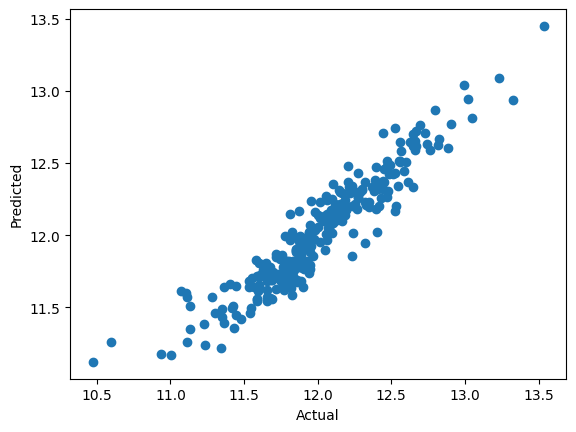

In [93]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

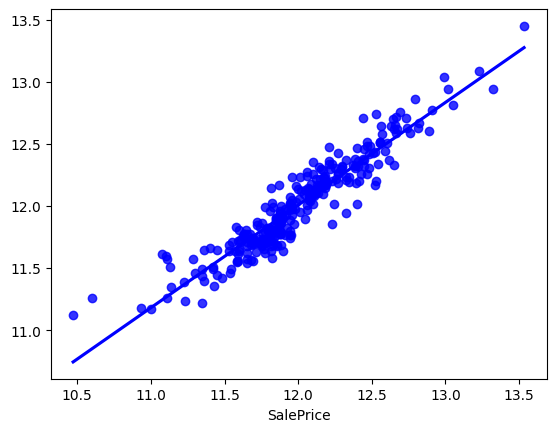

In [95]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='b')

Difference between Actual and Predicted Values

In [96]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
892,11.947956,11.794994,0.152962
1105,12.691584,12.760900,-0.069317
413,11.652696,11.712490,-0.059794
522,11.976666,11.976610,0.000056
1036,12.661917,12.591722,0.070195
...,...,...,...
479,11.401681,11.661280,-0.259599
1361,12.468441,12.511905,-0.043464
802,12.149508,12.217355,-0.067847
651,11.589896,11.717620,-0.127724
